## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [3]:
import torch
import numpy as np
import math

In [4]:
# Group actions

def group_action(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', A, y) + x

def group_action_inv(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bjk,bk->bj', torch.linalg.inv(A), y - x)

def group_action_func(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor, f: callable) -> torch.Tensor:
    y_inv = group_action_inv(x, A, y)
    return f(y_inv)

In [5]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, b: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = 0.5 * (a + c)

    # Define B = A - mI
    B00 = 0.5 * (a - c)
    B01 = b
    B10 = b
    B11 = -0.5 * (a - c)

    # Compute s = sqrt(b^2 + ((a-c)/2)^2)
    s = torch.sqrt(b**2 + (0.5 * (a - c))**2)

    # Handle s=0 case with safe division
    sinhc = torch.where(s > 1e-12, torch.sinh(s) / s, torch.ones_like(s))

    # exp(A) = exp(m) * (cosh(s) * I + (sinh(s)/s) * B)
    expm = torch.zeros(m.shape + (2, 2), dtype=m.dtype, device=a.device)
    expm[..., 0, 0] = torch.cosh(s) + sinhc * B00
    expm[..., 0, 1] = sinhc * B01
    expm[..., 1, 0] = sinhc * B10
    expm[..., 1, 1] = torch.cosh(s) + sinhc * B11

    return torch.exp(m)[..., None, None] * expm




In [6]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=1)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # calc all parameters
    alpha = w[0]
    a = w[1]
    b = w[2]
    c = w[3]
    theta = w[4]
    x1 = w[5]
    x2 = w[6]

    Y = exp_SNM(a, b, c)

    A = torch.bmm(exp_SO(theta), Y)
    x = torch.stack([x1, x2]).permute(1, 0)

    return torch.sigmoid(alpha) * group_action_func(x, A, y, gaussian)


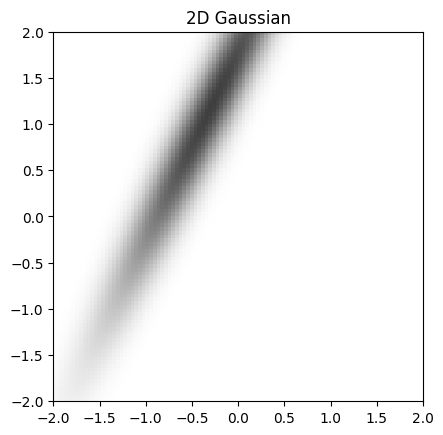

In [25]:

# plot 2D image of gaussian function

import matplotlib.pyplot as plt

# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
points = np.stack([xv, yv], axis=-1)  # shape (100, 100, 2)

x = torch.tensor([-0.2805,1.2112])
# 1.1102,  0.7595, -0.3787, -1.3284,  0.3944, -0.2805,  1.2112

a = torch.tensor([0.7595])
b = torch.tensor([-0.3787])
c = torch.tensor([-1.3284])
theta = torch.tensor([1.2944])

# Evaluate gaussian at each point
gauss_img = np.zeros((100, 100))
for i in range(100):
	for j in range(100):
		gauss_img[i, j] = torch.sigmoid(torch.tensor(1.1102))*group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[i, j]], dtype=torch.float), gaussian)

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, extent=[-2, 2, -2, 2], origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

In [8]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate, epochs, batches, target):
    # Prepare training data as a batch for vectorized computation
    inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])  # shape (25, 2)
    targets = torch.stack([target.flatten()]*batches)  # shape (25, )

    w = torch.randn(7, batches, requires_grad=True, device=device)

    for epoch in range(epochs):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            
        # Vectorized forward pass
        preds = torch.stack([
            f_hat(w, torch.stack([x] * batches)) for x in inputs
        ]).permute(1, 0) 

        eps = 1e-18 # counteract floating point inprecision
        
        loss = torch.sqrt(torch.sum((targets - preds)**2, 1)  + eps).mean()
        loss.backward()
        with torch.no_grad():
            if (epoch + 1) % 10 == 0:
                print(w.grad.sum(1))
            w -= learning_rate * w.grad
        w.grad.zero_()

    preds = torch.stack([f_hat(w, torch.stack([x] * batches)) for x in inputs]).permute(1, 0)
    loss = torch.sqrt(torch.sum((targets - preds)**2, 1))

    return loss, w

In [9]:
# plot 2D image of gaussian function
def plot_image(w: torch.Tensor, resolution=25):
    w = w.to(torch.device("cpu"))
    # Create a grid of points
    xv, yv = np.meshgrid(np.linspace(-2, 2, resolution), np.linspace(-2, 2, resolution))
    points = torch.tensor(np.stack([xv, yv], axis=-1), dtype=torch.float)  # shape (100, 100, 2)

    print(torch.stack([w]))
    # Evaluate gaussian at each point
    gauss_img = np.zeros((resolution, resolution))
    for i in range(0, resolution):
        for j in range(0, resolution):
            gauss_img[i, j] = f_hat(w.unsqueeze(1), torch.stack([points[i, j]]))

    plt.title("2D Gaussian")
    plt.imshow(1-gauss_img, origin='lower', cmap='gray', vmin=0, vmax=1)
    plt.show()

In [10]:
learning_rate = 1
epochs = 500
batches = 5

# create a 4x4 tensor with all the same value a=0.3
a = 0.5
output_z = torch.full((5, 5), a, device=device)

loss, w = train(learning_rate, epochs, batches, output_z)

min_index = torch.argmin(loss)



Epoch 10/500
tensor([-0.0581, -0.1525,  0.0678, -0.1261, -0.1669,  0.0261,  0.0296],
       device='cuda:0')
Epoch 20/500
tensor([ 9.8167e-02, -1.3258e-01, -1.1242e-04, -4.2892e-02,  8.4326e-03,
        -2.4764e-02, -2.4206e-02], device='cuda:0')
Epoch 30/500
tensor([-0.0016, -0.0714,  0.0005, -0.0975, -0.0982, -0.0235, -0.0222],
       device='cuda:0')
Epoch 40/500
tensor([-0.0312, -0.0746, -0.0004, -0.0705,  0.0540, -0.0751, -0.0984],
       device='cuda:0')
Epoch 50/500
tensor([-0.2895, -0.0803, -0.0344, -0.1130, -0.0434, -0.0245, -0.0224],
       device='cuda:0')
Epoch 60/500
tensor([-0.6274, -0.1425, -0.0018, -0.1535,  0.1006, -0.0232, -0.0072],
       device='cuda:0')
Epoch 70/500
tensor([-0.4622, -0.0988,  0.0322, -0.0958,  0.0788, -0.0154, -0.0118],
       device='cuda:0')
Epoch 80/500
tensor([-0.5814, -0.1037,  0.0394, -0.1245,  0.0494, -0.0125, -0.0192],
       device='cuda:0')
Epoch 90/500
tensor([-0.7344, -0.1207,  0.0895, -0.2429, -0.0046,  0.0029, -0.0178],
       device=

In [11]:
print(loss)
inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])
preds = torch.stack([
    f_hat(w, torch.stack([x] * batches)) for x in inputs
]).permute(1, 0) 
print(preds)

tensor([0.1643, 0.1625, 0.1387, 0.1643, 0.1629], device='cuda:0',
       grad_fn=<SqrtBackward0>)
tensor([[0.5270, 0.5325, 0.5340, 0.5312, 0.5244, 0.5322, 0.5378, 0.5394, 0.5367,
         0.5299, 0.5333, 0.5391, 0.5407, 0.5381, 0.5313, 0.5305, 0.5363, 0.5380,
         0.5354, 0.5288, 0.5237, 0.5295, 0.5312, 0.5288, 0.5223],
        [0.5221, 0.5283, 0.5301, 0.5276, 0.5209, 0.5294, 0.5355, 0.5372, 0.5345,
         0.5275, 0.5329, 0.5388, 0.5404, 0.5375, 0.5303, 0.5325, 0.5382, 0.5396,
         0.5366, 0.5292, 0.5282, 0.5337, 0.5349, 0.5317, 0.5243],
        [0.4673, 0.4724, 0.4735, 0.4708, 0.4643, 0.4726, 0.4778, 0.4790, 0.4764,
         0.4698, 0.4739, 0.4792, 0.4806, 0.4780, 0.4715, 0.4713, 0.4767, 0.4781,
         0.4756, 0.4692, 0.4648, 0.4702, 0.4716, 0.4693, 0.4630],
        [0.5273, 0.5329, 0.5343, 0.5316, 0.5247, 0.5322, 0.5379, 0.5395, 0.5368,
         0.5299, 0.5332, 0.5390, 0.5406, 0.5380, 0.5313, 0.5302, 0.5361, 0.5378,
         0.5353, 0.5287, 0.5233, 0.5292, 0.5311, 0.5287,

tensor([[-0.0774,  2.7497,  0.0073,  2.7344,  0.6016, -0.1227, -0.1596]],
       grad_fn=<StackBackward0>)


/tmp/ipykernel_9087/242344145.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  gauss_img[i, j] = f_hat(w.unsqueeze(1), torch.stack([points[i, j]]))


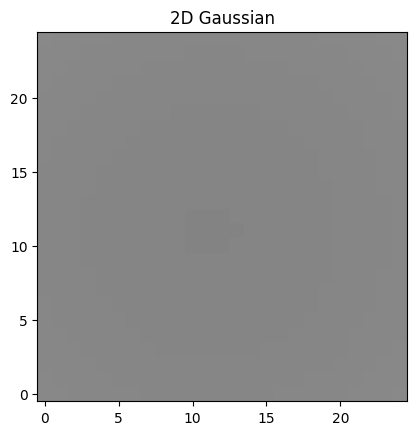

In [12]:
plot_image(w[:, min_index], 25)

In [19]:
learning_rate = 0.1
epochs = 100
batches = 100

# create a 5x5 with a black stripe in the middle
output_z = torch.stack([torch.tensor([0]*5), torch.tensor([0]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/100
tensor([-0.0081, -0.0320,  0.0134, -0.0295,  0.0081,  0.0787,  0.0518],
       device='cuda:0')
Epoch 20/100
tensor([-0.0114, -0.0354,  0.0020, -0.0239,  0.0645,  0.0859,  0.0196],
       device='cuda:0')
Epoch 30/100
tensor([-0.0165, -0.0305,  0.0071, -0.0237,  0.0279,  0.0486,  0.0102],
       device='cuda:0')
Epoch 40/100
tensor([-0.0181, -0.0300,  0.0049, -0.0227,  0.0220,  0.0430,  0.0088],
       device='cuda:0')
Epoch 50/100
tensor([-0.0195, -0.0299,  0.0042, -0.0221,  0.0142,  0.0366,  0.0071],
       device='cuda:0')
Epoch 60/100
tensor([-0.0206, -0.0299,  0.0046, -0.0219,  0.0048,  0.0305,  0.0055],
       device='cuda:0')
Epoch 70/100
tensor([-0.0216, -0.0300,  0.0054, -0.0217, -0.0038,  0.0257,  0.0042],
       device='cuda:0')
Epoch 80/100
tensor([-0.0226, -0.0299,  0.0061, -0.0217, -0.0106,  0.0223,  0.0032],
       de

tensor(1.1203, device='cuda:0', grad_fn=<SelectBackward0>)
tensor([[ 0.2160, -0.6567,  1.2912,  0.7131,  0.5425,  0.0071, -0.1882]],
       grad_fn=<StackBackward0>)


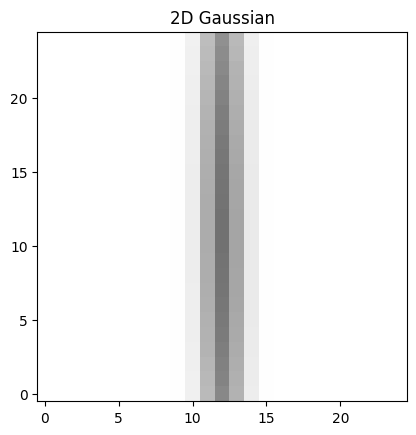

In [20]:
print(loss[min_index])

plot_image(w[:, min_index], 25)

In [21]:
learning_rate = 1
epochs = 100
batches = 100

# create a 4x4 tensor with all the same value a=0.3
output_z = torch.stack([torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/100
tensor([-0.0751, -0.1100, -0.0061, -0.1178,  0.0199,  0.0682,  0.0133],
       device='cuda:0')
Epoch 20/100
tensor([-0.0827, -0.1108, -0.0050, -0.1264,  0.0203,  0.0685, -0.0025],
       device='cuda:0')
Epoch 30/100
tensor([-0.0891, -0.1116, -0.0035, -0.1345,  0.0174,  0.0624, -0.0012],
       device='cuda:0')
Epoch 40/100
tensor([-0.0950, -0.1141, -0.0038, -0.1375,  0.0218,  0.0731, -0.0011],
       device='cuda:0')
Epoch 50/100
tensor([-0.1003, -0.1161, -0.0021, -0.1422,  0.0214,  0.0776, -0.0014],
       device='cuda:0')
Epoch 60/100
tensor([-1.0554e-01, -1.1816e-01, -7.6081e-05, -1.4701e-01,  2.0014e-02,
         8.1131e-02, -3.7289e-05], device='cuda:0')
Epoch 70/100
tensor([-0.1108, -0.1198,  0.0023, -0.1517,  0.0199,  0.0843,  0.0012],
       device='cuda:0')
Epoch 80/100
tensor([-0.1164, -0.1219,  0.0045, -0.1560,  0.0176,

tensor([[ 0.9026,  1.9928,  0.5076,  1.0702,  1.1386, -1.1887, -0.3549]],
       grad_fn=<StackBackward0>)


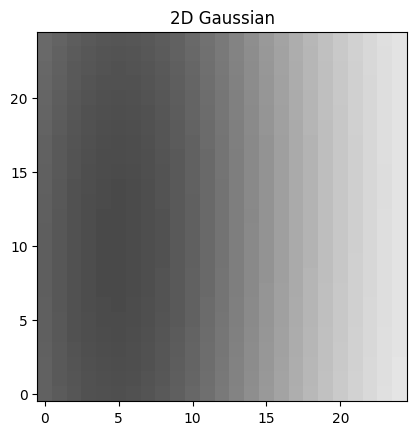

In [22]:
plot_image(w[:, min_index], 25)